<a href="https://colab.research.google.com/github/omkarhegganna/ML2/blob/main/program7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Generate a Synthetic Unsupervised Dataset
We'll use `make_blobs` from `sklearn.datasets` to create a 2D dataset that is easy to visualize.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Generate 2D synthetic data
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=42)

# Convert to a DataFrame (dropping the true labels to keep it unsupervised)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
display(df.head())

,Feature_1,Feature_2
0,-9.606585,8.376399
1,-4.081045,9.507428
2,-8.985774,7.159889
3,5.224951,1.884935
4,4.982413,2.654509


### 2. Preprocess the Data
We'll scale the features using `StandardScaler` to ensure that both features contribute equally to the distance calculations.

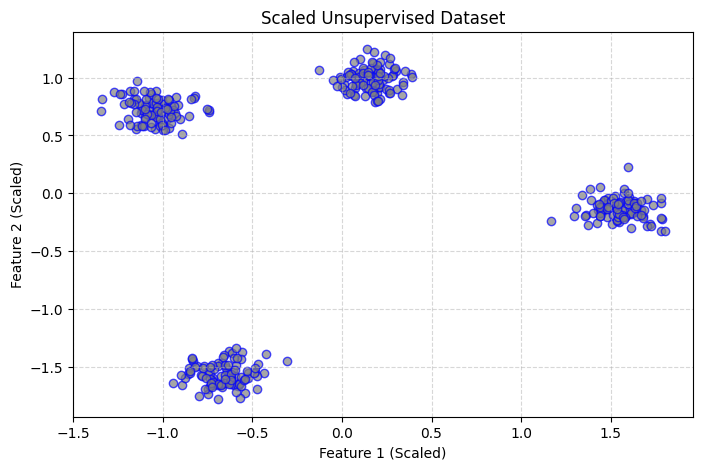

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Plot the unclustered data
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', alpha=0.7, edgecolors='b')
plt.title("Scaled Unsupervised Dataset")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 3. Determine the Optimal Number of Clusters (Elbow Method)
We run K-Means for a range of cluster values and plot the Within-Cluster Sum of Squares (inertia).

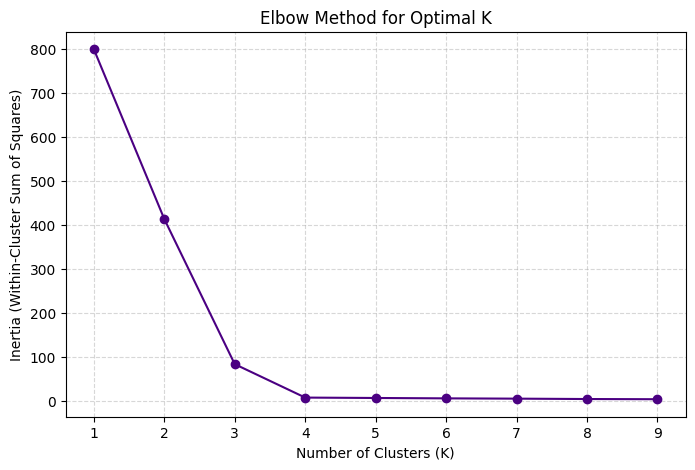

In [3]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='indigo')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4. Train K-Means and Visualize Clusters
Based on the elbow plot, 4 is the optimal number of clusters. Let's fit the final model and plot the clusters along with their centroids.

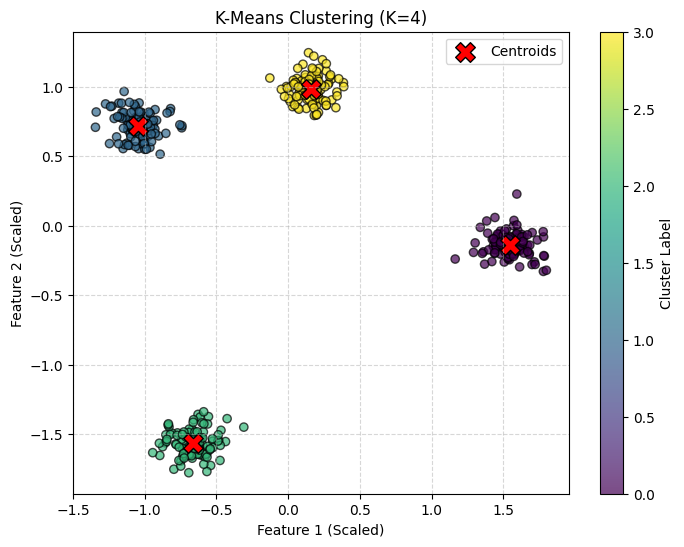

In [4]:
# Apply K-Means with K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add the cluster assignments back to our DataFrame
df['Cluster'] = cluster_labels

# Plot the clustered data and centroids
plt.figure(figsize=(8, 6))
sctr = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7, edgecolors='k')

# Plot centroids
centroids = kmeans_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

plt.title(f"K-Means Clustering (K={optimal_k})")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.colorbar(sctr, label='Cluster Label')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()